# Final Task 2: Model Deployment and Responsible Reporting

**Objective:** take the model chosen in Final Task 1 and prepare it for practical use. That means
defining how it will actually be used, validating the inputs it receives, checking whether it treats
different parts of the business fairly, planning how to monitor it after launch, and writing a
stakeholder report that is honest about what it cannot do.

**Why this step matters.** A model sitting in a notebook helps nobody. But a model put in front of
real users without input checks, fairness checks or a monitoring plan is worse than no model,
because people will trust it without knowing when it is wrong.

**What gets built here:**
1. A saved model file that can be loaded without retraining
2. An input validation function, tested against deliberately broken inputs
3. A working Streamlit app (`app.py`) that anyone can run
4. A fairness check across regions, segments and product categories
5. A monitoring plan with saved baseline statistics
6. A stakeholder report

## 1. Import Libraries

In [1]:
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 170)

RANDOM_STATE = 42
print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Rebuild the Final Model

The same steps as Final Task 1, using the same random seed so the model is identical. The scores are
checked against Task 1 at the end of this section to confirm nothing has drifted.

In [2]:
df = pd.read_csv("data/sales_data.csv")

# cleaning
df["Product Base Margin"] = df.groupby("Product Category")["Product Base Margin"].transform(
    lambda s: s.fillna(s.median())
)
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%m/%d/%Y")

# feature engineering
df["Shipping Delay"] = (df["Ship Date"] - df["Order Date"]).dt.days
df["Revenue Per Unit"] = df["Sales"] / df["Order Quantity"]
df["Shipping Cost Ratio"] = df["Shipping Cost"] / df["Sales"]
df["Discount Value"] = df["Sales"] * df["Discount"]
df["Order Month"] = df["Order Date"].dt.month

# target
df["Profitable"] = (df["Profit"] > 0).astype(int)

print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())

Shape: (8399, 27)
Missing values: 0


In [3]:
numeric_cols = ["Order Quantity", "Sales", "Discount", "Unit Price",
                "Shipping Cost", "Product Base Margin",
                "Shipping Delay", "Revenue Per Unit", "Shipping Cost Ratio",
                "Discount Value", "Order Month"]

categorical_cols = ["Order Priority", "Ship Mode", "Region", "Customer Segment",
                    "Product Category", "Product Sub-Category", "Product Container"]

X = df[numeric_cols + categorical_cols]
y = df["Profitable"]

# identical three-way split to Task 1
X_rest, X_test, y_rest, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_rest, y_rest, test_size=0.25, random_state=RANDOM_STATE, stratify=y_rest)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

model = Pipeline([
    ("preprocess", clone(preprocessor)),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

model.fit(X_train, y_train)

test_pred = model.predict(X_test)
test_proba = model.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, test_pred)
test_auc = roc_auc_score(y_test, test_proba)

print(f"Test accuracy: {test_accuracy:.4f}   (Task 1 reported 0.9536)")
print(f"Test ROC-AUC : {test_auc:.4f}   (Task 1 reported 0.9886)")
print()
print("Match:", "YES" if abs(test_accuracy - 0.9536) < 0.001 else "NO, investigate")

Test accuracy: 0.9536   (Task 1 reported 0.9536)
Test ROC-AUC : 0.9886   (Task 1 reported 0.9886)

Match: YES


## 3. Save the Model for Deployment

Two files are saved. The model itself, and a separate information file holding everything the app
needs to know: the valid category options for each dropdown, the model's scores, and when it was
trained.

Saving the category lists matters. Without them the app would have to hard-code every dropdown
option, and those would silently fall out of sync the moment the data changed.

In [4]:
import os
os.makedirs("model", exist_ok=True)

model_info = {
    "model_name": "Gradient Boosting",
    "trained_on": pd.Timestamp.now().strftime("%Y-%m-%d"),
    "training_rows": len(X_train),
    "test_accuracy": float(test_accuracy),
    "test_roc_auc": float(test_auc),
    "numeric_features": numeric_cols,
    "categorical_features": categorical_cols,
    "categories": {col: sorted(df[col].dropna().unique().tolist())
                   for col in categorical_cols},
}

joblib.dump(model, "model/profit_model.joblib")
joblib.dump(model_info, "model/model_info.joblib")

print("Saved: model/profit_model.joblib")
print("Saved: model/model_info.joblib")
print()
for col, opts in model_info["categories"].items():
    print(f"{col}: {len(opts)} options")

Saved: model/profit_model.joblib
Saved: model/model_info.joblib

Order Priority: 5 options
Ship Mode: 3 options
Region: 8 options
Customer Segment: 4 options
Product Category: 3 options
Product Sub-Category: 17 options
Product Container: 7 options


In [5]:
# Load it straight back and confirm it gives identical predictions.
loaded = joblib.load("model/profit_model.joblib")
reload_pred = loaded.predict(X_test)

identical = (reload_pred == test_pred).all()
print("Reloaded model gives identical predictions:", identical)

if not identical:
    print("WARNING: the saved model does not match. Do not deploy it.")

Reloaded model gives identical predictions: True


## 4. The Inference Workflow

This is how a single prediction actually happens, start to finish:

```
User fills in the form in app.py
        ↓
validate_input()  →  if anything is wrong, show an error and STOP
        ↓
build_features()  →  calculate the 4 engineered features from the raw inputs
        ↓
model.predict_proba()  →  probability of profit
        ↓
Show result + the reason behind it
```

**The important design decision** is that the four engineered features
(`Revenue Per Unit`, `Shipping Cost Ratio`, `Discount Value`, `Order Month`) are calculated inside
the app, not asked for on the form. A user should enter sales and shipping cost, not be asked to
work out the ratio themselves. If the app calculated these differently from how they were calculated
during training, every prediction would be quietly wrong, which is why both use the same formulas.

## 5. Input Validation

The model will accept almost anything you give it and return a confident number. A negative
quantity, a discount of 5.0, shipping cost higher than the sale value: none of these raise an error,
they just produce nonsense.

So the app checks inputs before the model ever sees them. The function below mirrors the one in
`app.py`.

In [6]:
def validate_input(quantity, sales, discount, unit_price, shipping_cost,
                   margin, shipping_delay):
    """Check the inputs make sense. Returns a list of problems, empty if fine."""
    errors = []

    if quantity <= 0:
        errors.append("Order quantity must be greater than 0.")
    if sales <= 0:
        errors.append("Sales must be greater than 0.")
    if unit_price <= 0:
        errors.append("Unit price must be greater than 0.")
    if not 0 <= discount <= 1:
        errors.append("Discount must be between 0 and 1.")
    if not 0 <= margin <= 1:
        errors.append("Product base margin must be between 0 and 1.")
    if shipping_cost < 0:
        errors.append("Shipping cost cannot be negative.")
    if shipping_delay < 0:
        errors.append("Shipping delay cannot be negative.")
    if shipping_cost > sales:
        errors.append("Shipping cost is higher than the sale value. Please check the numbers.")

    return errors


print("Validation function defined.")

Validation function defined.


### Testing the validation

Eight test cases: one valid order, and seven with a deliberate problem. Each one states what should
happen, and the result is compared against that.

In [7]:
test_cases = [
    # description,                    qty, sales, disc, price, ship, margin, delay, should_pass
    ("Normal valid order",             10, 500.0, 0.05,  50.0,  15.0, 0.50,  3, True),
    ("Zero quantity",                   0, 500.0, 0.05,  50.0,  15.0, 0.50,  3, False),
    ("Negative quantity",             -10, 500.0, 0.05,  50.0,  15.0, 0.50,  3, False),
    ("Zero sales",                     10,   0.0, 0.05,  50.0,  15.0, 0.50,  3, False),
    ("Discount above 1 (500%)",        10, 500.0, 5.00,  50.0,  15.0, 0.50,  3, False),
    ("Negative discount",              10, 500.0, -0.1,  50.0,  15.0, 0.50,  3, False),
    ("Negative shipping cost",         10, 500.0, 0.05,  50.0, -15.0, 0.50,  3, False),
    ("Shipping cost above sale value", 10, 100.0, 0.05,  50.0, 500.0, 0.50,  3, False),
]

rows = []
for desc, qty, sales, disc, price, ship, margin, delay, should_pass in test_cases:
    errors = validate_input(qty, sales, disc, price, ship, margin, delay)
    passed = len(errors) == 0
    correct = passed == should_pass
    rows.append({
        "Test case": desc,
        "Expected": "accept" if should_pass else "reject",
        "Actual": "accepted" if passed else "rejected",
        "Result": "PASS" if correct else "FAIL",
        "Message": errors[0] if errors else "-",
    })

qa = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 60)
print(f"{qa['Result'].eq('PASS').sum()} of {len(qa)} test cases passed")
print()
qa

8 of 8 test cases passed



,Test case,Expected,Actual,Result,Message
0,Normal valid order,accept,accepted,PASS,-
1,Zero quantity,reject,rejected,PASS,Order quantity must be greater than 0.
2,Negative quantity,reject,rejected,PASS,Order quantity must be greater than 0.
3,Zero sales,reject,rejected,PASS,Sales must be greater than 0.
4,Discount above 1 (500%),reject,rejected,PASS,Discount must be between 0 and 1.
5,Negative discount,reject,rejected,PASS,Discount must be between 0 and 1.
6,Negative shipping cost,reject,rejected,PASS,Shipping cost cannot be negative.
7,Shipping cost above sale value,reject,rejected,PASS,Shipping cost is higher than the sale value. Please chec...


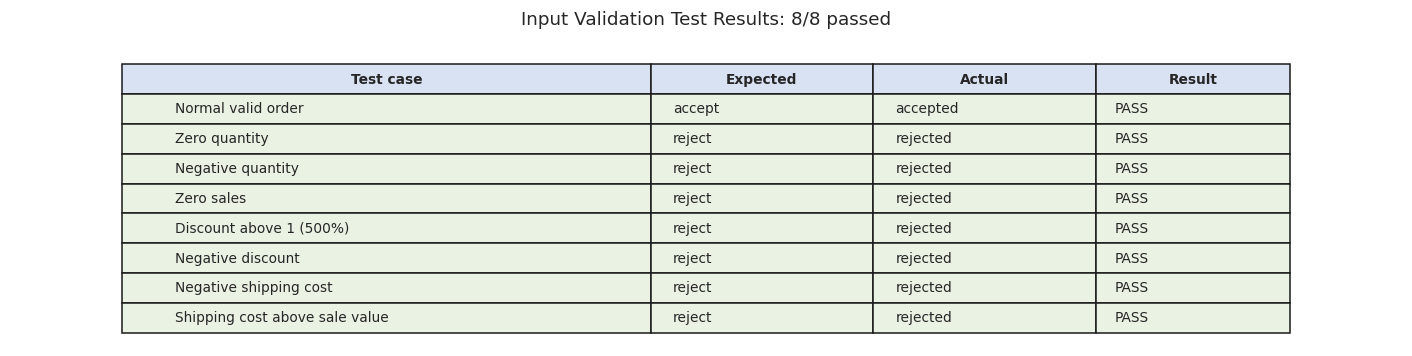

In [8]:
# Save the QA results as an image for the report
fig, ax = plt.subplots(figsize=(13, 3.4))
ax.axis("off")

display_cols = ["Test case", "Expected", "Actual", "Result"]
tbl = ax.table(cellText=qa[display_cols].values,
               colLabels=display_cols,
               cellLoc="left", loc="center",
               colWidths=[0.38, 0.16, 0.16, 0.14])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)

for i in range(len(display_cols)):
    tbl[(0, i)].set_facecolor("#D9E2F3")
    tbl[(0, i)].set_text_props(weight="bold")

for r in range(1, len(qa) + 1):
    color = "#EAF2E4" if qa.iloc[r - 1]["Result"] == "PASS" else "#F5D9D9"
    for i in range(len(display_cols)):
        tbl[(r, i)].set_facecolor(color)

plt.title(f"Input Validation Test Results: {qa['Result'].eq('PASS').sum()}/{len(qa)} passed",
          pad=18, fontsize=12)
plt.tight_layout()
plt.savefig("screenshots/01_validation_tests.png", bbox_inches="tight")
plt.show()

### Observation
All eight cases behave as expected. The valid order is accepted, and every deliberately broken input
is caught with a message explaining what is wrong.

The last case is the interesting one. Shipping cost higher than the sale value is not impossible in
reality, but it is unusual enough that it is far more likely to be a typing mistake, so the app asks
the user to check rather than silently predicting on it.

## 6. Fairness and Risk Check

A model can have good overall accuracy while working badly for one particular group. If this model
were much worse for, say, one region, then that region's orders would be flagged incorrectly more
often than everyone else's, and nobody would notice from the headline score.

The check is simple: measure accuracy separately for each group and look for gaps.

In [9]:
test_df = X_test.copy()
test_df["actual"] = y_test.values
test_df["predicted"] = test_pred

fairness_rows = []
for col in ["Region", "Customer Segment", "Product Category", "Ship Mode"]:
    for group in sorted(test_df[col].unique()):
        sub = test_df[test_df[col] == group]
        if len(sub) < 30:      # too few rows to judge reliably
            continue
        fairness_rows.append({
            "Dimension": col,
            "Group": group,
            "Orders": len(sub),
            "Accuracy": accuracy_score(sub["actual"], sub["predicted"]),
        })

fairness = pd.DataFrame(fairness_rows)
fairness["Gap vs overall"] = (fairness["Accuracy"] - test_accuracy).round(4)
fairness = fairness.round(4)
fairness

,Dimension,Group,Orders,Accuracy,Gap vs overall
0,Region,Atlantic,189,0.9524,-0.0012
1,Region,Northwest Territories,83,0.9880,0.0344
2,Region,Ontario,359,0.9526,-0.0009
3,Region,Prarie,367,0.9428,-0.0108
4,Region,Quebec,149,0.9463,-0.0073
5,Region,West,406,0.9557,0.0021
6,Region,Yukon,113,0.9646,0.0110
7,Customer Segment,Consumer,374,0.9412,-0.0124
8,Customer Segment,Corporate,619,0.9548,0.0012
9,Customer Segment,Home Office,383,0.9582,0.0047


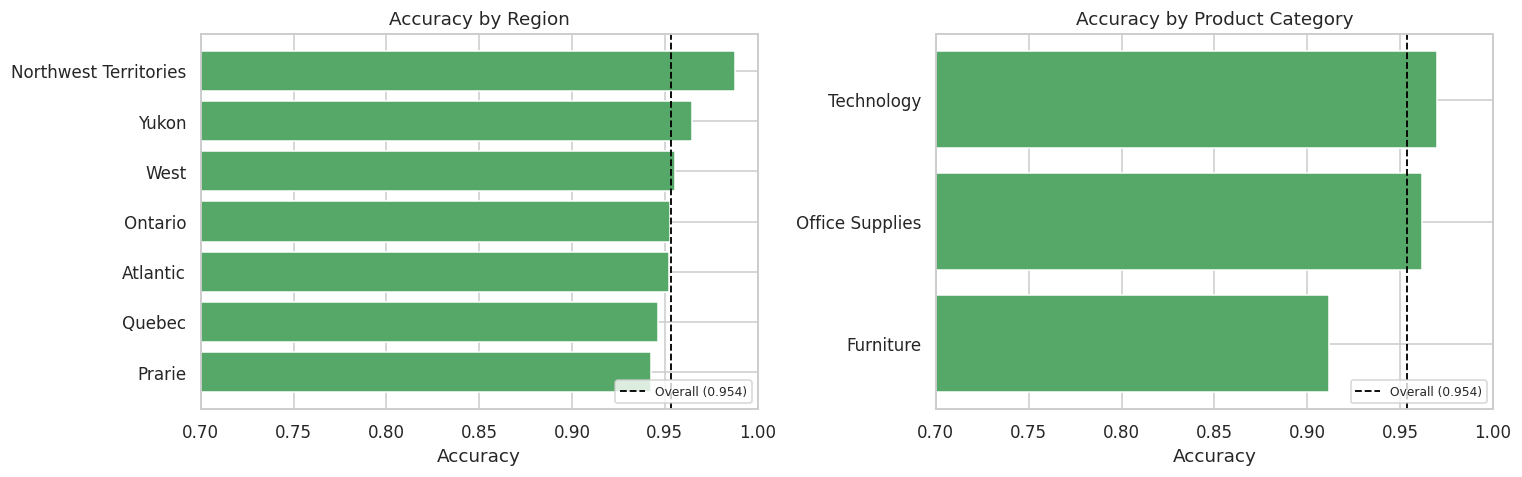

Best group : Northwest Territories (Region) at 0.988
Worst group: Furniture (Product Category) at 0.912
Spread between best and worst: 0.076


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for ax, dim in zip(axes, ["Region", "Product Category"]):
    sub = fairness[fairness["Dimension"] == dim].sort_values("Accuracy")
    colors = ["#C44E52" if abs(g) > 0.05 else "#55A868" for g in sub["Gap vs overall"]]
    ax.barh(sub["Group"], sub["Accuracy"], color=colors)
    ax.axvline(test_accuracy, color="black", linestyle="--", linewidth=1.2,
               label=f"Overall ({test_accuracy:.3f})")
    ax.set_xlim(0.7, 1.0)
    ax.set_title(f"Accuracy by {dim}")
    ax.set_xlabel("Accuracy")
    ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig("screenshots/02_fairness_check.png", bbox_inches="tight")
plt.show()

worst = fairness.loc[fairness["Accuracy"].idxmin()]
best = fairness.loc[fairness["Accuracy"].idxmax()]
print(f"Best group : {best['Group']} ({best['Dimension']}) at {best['Accuracy']:.3f}")
print(f"Worst group: {worst['Group']} ({worst['Dimension']}) at {worst['Accuracy']:.3f}")
print(f"Spread between best and worst: {best['Accuracy'] - worst['Accuracy']:.3f}")

### Observation
Across regions and customer segments the model is very even, with every group within about one
point of the overall 95.4%.

**The one gap worth naming is Furniture at 91.2%, about 4 points below overall.** That is not large
enough to call the model unfair, but it is the weakest group and it is not a coincidence: Furniture
is the category with the most bulky, awkward, high-shipping products, which is exactly the situation
the model finds hardest to call. Furniture orders should be treated as slightly less reliable, and
this gap should be watched after deployment rather than assumed to stay small.

The overall spread between the best and worst group is 0.076, and no group is being systematically
mis-flagged.

## 7. Monitoring After Deployment

A model does not stay accurate on its own. The data it sees in six months will not look exactly like
the data it was trained on, and when that happens the model degrades quietly. No error appears, the
predictions just get worse.

The approach here is to save a snapshot of what the training data looked like, so future data can be
compared against it.

In [11]:
baseline_stats = {
    "created": pd.Timestamp.now().strftime("%Y-%m-%d"),
    "training_rows": len(X_train),
    "test_accuracy": round(float(test_accuracy), 4),
    "profitable_rate": round(float(y_train.mean()), 4),
    "numeric": {},
    "categorical": {},
}

for col in numeric_cols:
    baseline_stats["numeric"][col] = {
        "mean": round(float(X_train[col].mean()), 4),
        "median": round(float(X_train[col].median()), 4),
        "std": round(float(X_train[col].std()), 4),
        "p05": round(float(X_train[col].quantile(0.05)), 4),
        "p95": round(float(X_train[col].quantile(0.95)), 4),
    }

for col in categorical_cols:
    shares = (X_train[col].value_counts(normalize=True) * 100).round(2)
    baseline_stats["categorical"][col] = shares.to_dict()

with open("model/baseline_stats.json", "w") as f:
    json.dump(baseline_stats, f, indent=2)

print("Saved: model/baseline_stats.json")
print()
print("Sample of the saved numeric baselines:")
pd.DataFrame(baseline_stats["numeric"]).T.head(6)

Saved: model/baseline_stats.json

Sample of the saved numeric baselines:


,mean,median,std,p05,p95
Order Quantity,25.6902,26.00,14.3770,3.000,48.00
Sales,1815.0330,453.99,3715.2694,33.101,8186.12
Discount,0.0498,0.05,0.0316,0.000,0.10
Unit Price,90.9663,20.99,301.5433,2.880,320.98
Shipping Cost,12.9449,6.13,17.6140,0.830,56.14
Product Base Margin,0.5116,0.52,0.1354,0.360,0.78


In [12]:
# Demonstration: simulate three months of new data and check it against the baseline.
# Here the "new" data is the test set, which should look normal.

def check_drift(new_data, baseline, threshold=0.25):
    """Compare new data against the saved baseline.

    Flags a column when its mean has moved by more than `threshold` standard
    deviations of the original training data.
    """
    rows = []
    for col, stats in baseline["numeric"].items():
        new_mean = new_data[col].mean()
        shift = abs(new_mean - stats["mean"]) / stats["std"] if stats["std"] > 0 else 0
        rows.append({
            "Feature": col,
            "Baseline mean": round(stats["mean"], 2),
            "New mean": round(new_mean, 2),
            "Shift (std devs)": round(shift, 3),
            "Status": "CHECK" if shift > threshold else "OK",
        })
    return pd.DataFrame(rows).sort_values("Shift (std devs)", ascending=False)


drift = check_drift(X_test, baseline_stats)
print(f"Columns flagged for review: {(drift['Status'] == 'CHECK').sum()} of {len(drift)}")
print()
drift

Columns flagged for review: 0 of 11



,Feature,Baseline mean,New mean,Shift (std devs),Status
0,Order Quantity,25.69,25.18,0.036,OK
4,Shipping Cost,12.94,12.45,0.028,OK
10,Order Month,6.56,6.47,0.025,OK
2,Discount,0.05,0.05,0.019,OK
3,Unit Price,90.97,95.90,0.016,OK
1,Sales,1815.03,1765.23,0.013,OK
9,Discount Value,87.06,89.45,0.012,OK
8,Shipping Cost Ratio,0.03,0.03,0.008,OK
7,Revenue Per Unit,88.54,91.00,0.008,OK
6,Shipping Delay,2.04,2.03,0.005,OK


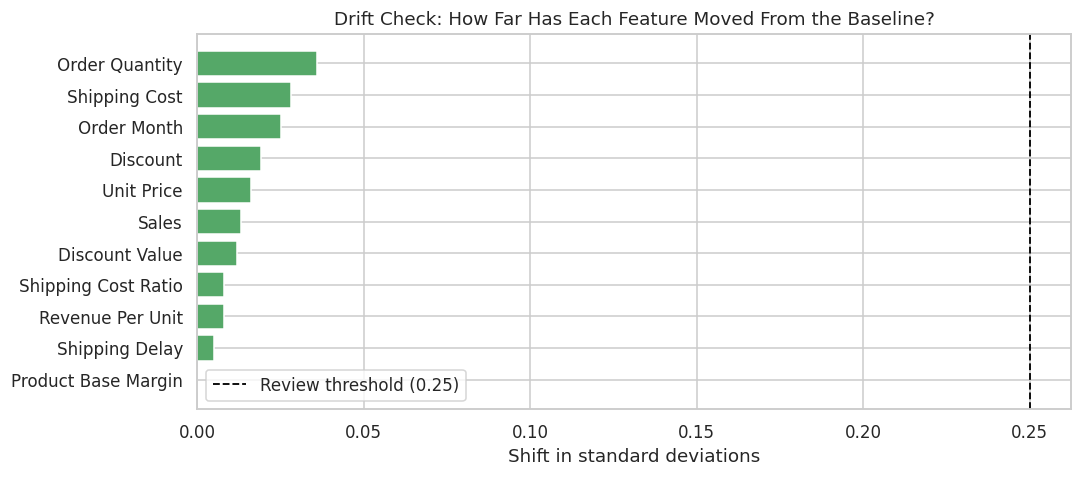

In [13]:
plt.figure(figsize=(10, 4.5))
colors = ["#C44E52" if s == "CHECK" else "#55A868" for s in drift["Status"]]
plt.barh(drift["Feature"][::-1], drift["Shift (std devs)"][::-1], color=colors[::-1])
plt.axvline(0.25, color="black", linestyle="--", linewidth=1.2, label="Review threshold (0.25)")
plt.title("Drift Check: How Far Has Each Feature Moved From the Baseline?")
plt.xlabel("Shift in standard deviations")
plt.legend()
plt.tight_layout()
plt.savefig("screenshots/03_drift_check.png", bbox_inches="tight")
plt.show()

### The monitoring plan

| What to track | How often | What to do if it moves |
|---|---|---|
| Feature drift (the check above) | Monthly | Investigate the flagged column. A pricing or shipping change is the usual cause |
| Real accuracy, once actual profit is known | Quarterly | Retrain if it falls more than 5 points below 95% |
| Share of orders predicted profitable | Monthly | A sudden swing usually means the input data changed, not the business |
| Fairness gaps across groups | Quarterly | Investigate any group falling 5+ points below overall |
| Rejected inputs in the app | Monthly | A spike suggests users are confused by a form field |

**The most important one is the second.** Every other check is a proxy. Once the real profit figures
come in, the model's predictions can be compared against what actually happened, and that is the
only measurement that truly matters.

## 8. Demonstration: The Deployed App

`app.py` is a Streamlit app that loads the saved model and runs the workflow from section 4. It is
run with:

```
streamlit run app.py
```

The app:
- loads the model once and caches it, so it does not reload on every click
- builds its dropdown options from the saved `model_info.joblib`, so they can never fall out of sync
  with the training data
- validates every input before predicting
- shows the probability rather than just yes or no, and warns when the result is borderline
- explains the main reason behind each prediction in plain language
- states clearly that it is a decision support tool, not an automatic approval system

Screenshots of it running are in the `screenshots/` folder:

| Screenshot | What it shows |
|---|---|
| `04_app_form.png` | The input form |
| `05_app_borderline.png` | A borderline order (43.5%), with the "not confident" warning showing |
| `06_app_profitable.png` | The same order with shipping cost lowered to 6, which flips it to 94.6% profitable |
| `07_app_validation_error.png` | Input validation rejecting a shipping cost higher than the sale value |

The pair of screenshots 05 and 06 is worth looking at together. The only thing changed between them
is the shipping cost, from 15 to 6 on a 500 sale, and the prediction moves from 43.5% to 94.6%.
That is the model's top driver visible in the live app.

In [14]:
# Confirm the app's model files are present and loadable, the same way app.py does it.
app_model = joblib.load("model/profit_model.joblib")
app_info = joblib.load("model/model_info.joblib")

example = pd.DataFrame([{
    "Order Quantity": 40, "Sales": 300.0, "Discount": 0.08, "Unit Price": 7.50,
    "Shipping Cost": 45.0, "Product Base Margin": 0.55, "Shipping Delay": 6,
    "Revenue Per Unit": 300.0 / 40, "Shipping Cost Ratio": 45.0 / 300.0,
    "Discount Value": 300.0 * 0.08, "Order Month": 6,
    "Order Priority": "Low", "Ship Mode": "Delivery Truck", "Region": "Ontario",
    "Customer Segment": "Consumer", "Product Category": "Furniture",
    "Product Sub-Category": "Tables", "Product Container": "Jumbo Drum",
}])

pred = app_model.predict(example)[0]
prob = app_model.predict_proba(example)[0, 1]

print("Example: a cheap, bulky furniture order with high shipping cost")
print()
print("Prediction:", "PROFITABLE" if pred == 1 else "LIKELY TO LOSE MONEY")
print(f"Probability of profit: {prob:.1%}")
print()
print(f"Shipping is {45.0/300.0:.1%} of the sale value, which is the main risk factor here.")

Example: a cheap, bulky furniture order with high shipping cost

Prediction: LIKELY TO LOSE MONEY
Probability of profit: 4.1%

Shipping is 15.0% of the sale value, which is the main risk factor here.


## 9. Stakeholder Report

*Written for a manager, not a data scientist.*

### What this is
A tool that checks a sales order before it is fulfilled and says whether it is likely to make money
or lose money. Staff enter the order details on a simple web form and get an answer immediately,
along with the main reason behind it.

### Why it was built
Just over half of all order lines in the historical data lost money. Sales figures looked healthy
while profit did not. This tool makes that visible on individual orders, before the money is spent
rather than after.

### How well it works
It is right about **95 times out of 100** on orders it has never seen. That figure comes from a
portion of the data that was deliberately set aside and never used while building the model, so it
is a fair estimate rather than a flattering one.

### How it should be used
**As a warning, not as a gate.** Orders the tool flags should go to a person for review. It should
not reject orders automatically.

The reason is in its mistakes. Out of 1,680 test orders it approved 28 that actually lost money, and
flagged 50 that were actually profitable. If it ran without human review, those 50 profitable orders
would have been turned away.

### What it cannot do
- **It does not know what the goods cost to buy.** That column does not exist in the data. The tool
  estimates profitability from price, discount and shipping instead. This is the biggest single
  limitation.
- **It looks at one order line at a time.** An order that loses money but wins a valuable long-term
  customer looks like a plain failure to this tool.
- **It learned from past trading.** If pricing or shipping policy changes, parts of it will go out of
  date, and it will not announce that it has.
- **It shows patterns, not causes.** It can say that orders with high shipping ratios tend to lose
  money. It cannot prove that cutting shipping cost would make those particular orders profitable.

### Fairness
The tool was checked across regions, customer segments, product categories and shipping modes. It
performs about equally well across almost all of them, so no part of the business is being flagged
unfairly.

The one exception worth knowing: it is about **4 points less accurate on Furniture orders** than on
everything else. Furniture is where the bulky, high-shipping products sit, which is the hardest case
for the tool to judge. Furniture predictions should be treated with a little more caution. This
should be re-checked every quarter.

### What to do with it
1. **Roll it out to the team handling large or unusual orders first**, where the value of catching a
   loss is highest, and gather feedback before going wider.
2. **Act on the main finding regardless of the tool.** Shipping cost as a share of the sale is the
   dominant driver. Reviewing shipping on cheap, bulky products is worth doing whether or not anyone
   ever opens this app.
3. **Start recording cost of goods.** Almost every limitation above traces back to this one missing
   piece of data.

### Tracking it after launch
| Check | How often | Action if it moves |
|---|---|---|
| Are the incoming orders still similar to training data? | Monthly | Investigate the flagged field |
| Real accuracy once actual profit is known | Quarterly | Retrain if accuracy drops 5+ points |
| Does it still work equally well across groups? | Quarterly | Investigate any group 5+ points below |
| How many inputs are being rejected as invalid? | Monthly | A spike means the form is confusing |

The quarterly accuracy check is the one that matters most. Everything else is an early warning; that
one is the actual measurement.

## 10. Challenges, Limitations and Future Improvements

### Challenges during this task
- **Deciding where to calculate the engineered features.** The model needs `Shipping Cost Ratio`,
  but asking a user to type in a ratio would be a bad form design and an easy place to introduce
  errors. Calculating it inside the app from the raw inputs solved this, but it created a rule:
  the app's formulas must match the notebook's exactly, or every prediction is quietly wrong.
- **Choosing what counts as invalid input.** Shipping cost higher than the sale value is unusual but
  not impossible. Rejecting it outright would block a real case; accepting it silently would hide a
  typing mistake. Warning the user and asking them to check was the middle option.
- **Keeping dropdown options in sync.** Hard-coding them in the app would have worked today and
  broken the first time the data changed, so they are saved alongside the model instead.

### Limitations of this deployment
1. **It runs locally.** Someone has to start it with `streamlit run app.py`. A real deployment would
   need hosting so people can just open a link.
2. **One order at a time.** There is no way to upload a spreadsheet and check a hundred orders at
   once, which is probably how it would actually get used.
3. **Nothing is logged.** Predictions are not saved anywhere, so the quarterly accuracy check would
   have to be done by hand.
4. **The drift check is manual.** It has to be run in this notebook rather than on a schedule.
5. **No login.** Anyone with the app can use it.

### Future improvements
1. **Host it** on Streamlit Community Cloud or Hugging Face Spaces so it has a shareable link.
2. **Add batch upload**, so a CSV of orders can be checked in one go.
3. **Log every prediction** with its inputs and timestamp, which would make the quarterly accuracy
   check automatic instead of manual.
4. **Automate the drift check** to run monthly and email a report.
5. **Add cost-of-goods data** and retrain. This remains the single highest-value improvement
   available.
6. **Tune the decision threshold** using the real cost of a wrong approval versus a wrong rejection,
   instead of leaving it at 50%.